# 06. Gene Expression Analysis

## TCGA-BRCA RNA-seq Expression Profiling

### Objective

This notebook investigates gene expression patterns across TCGA breast cancer samples, with a particular focus on differences among PAM50 molecular subtypes.

### Main goals

1. Obtain and inspect TCGA-BRCA RNA-seq gene expression data.
2. Perform basic quality control and expression filtering.
3. Match expression samples with clinical and PAM50 subtype annotations.
4. Explore global gene expression patterns using principal component analysis (PCA).
5. Identify subtype-associated expression patterns.
6. Generate expression visualisations for downstream differential expression and pathway analyses.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Project directories
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
processed_dir = data_dir / "processed"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

print("Project directory:", project_dir)
print("Processed data directory:", processed_dir)

Project directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA
Processed data directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/data/processed


In [3]:
# Check previously generated processed files
processed_files = sorted(processed_dir.glob("*"))

print("Files currently available in data/processed:")
for file in processed_files:
    print("-", file.name)

Files currently available in data/processed:
- tcga_brca_clinical_clean.csv
- tcga_brca_clinical_pam50.csv


In [4]:
# Load PAM50 clinical annotations generated in Notebook 05
pam50_file = processed_dir / "tcga_brca_clinical_pam50.csv"

pam50_df = pd.read_csv(pam50_file)

print("PAM50 dataset shape:", pam50_df.shape)
print("\nColumns:")
print(pam50_df.columns.tolist())

print("\nFirst 5 rows:")
display(pam50_df.head())

PAM50 dataset shape: (1098, 20)

Columns:
['case_id', 'patient_id', 'sex', 'race', 'ethnicity', 'age_at_diagnosis_days', 'age_at_diagnosis_years', 'primary_diagnosis', 'stage', 'pathologic_T', 'pathologic_N', 'pathologic_M', 'vital_status', 'days_to_death', 'latest_follow_up_days', 'overall_survival_days', 'overall_survival_event', 'pam50_subtype', 'stage_group', 'stage_binary']

First 5 rows:


,case_id,patient_id,sex,race,ethnicity,age_at_diagnosis_days,age_at_diagnosis_years,primary_diagnosis,stage,pathologic_T,pathologic_N,pathologic_M,vital_status,days_to_death,latest_follow_up_days,overall_survival_days,overall_survival_event,pam50_subtype,stage_group,stage_binary
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,female,white,not hispanic or latino,22279.0,60.996578,"Infiltrating duct carcinoma, NOS",Stage IA,T1c,N0 (mol+),M0,Alive,NaN,337.0,337.0,0.0,Luminal A,Stage I,Early stage
1,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,female,white,not hispanic or latino,25833.0,70.726899,Adenoid cystic carcinoma,Stage I,T1c,N0,M0,Alive,NaN,259.0,259.0,0.0,Normal-like,Stage I,Early stage
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,TCGA-A2-A04W,female,white,not hispanic or latino,18345.0,50.225873,Apocrine adenocarcinoma,Stage IIB,T2,N1mi,M0,Alive,NaN,3102.0,3102.0,0.0,HER2-enriched,Stage II,Early stage
3,00a2d166-78c9-4687-a195-3d6315c27574,TCGA-AN-A0AM,female,white,not hispanic or latino,20713.0,56.709103,"Infiltrating duct carcinoma, NOS",Stage IIA,T2,N0,M0,Alive,NaN,5.0,5.0,0.0,Luminal B,Stage II,Early stage
4,00b11ca8-8540-4a3d-b602-ec754b00230b,TCGA-LL-A440,female,white,not hispanic or latino,22497.0,61.593429,"Lobular carcinoma, NOS",Stage IA,T1c,N0 (i-),MX,Alive,NaN,759.0,759.0,0.0,Luminal A,Stage I,Early stage


In [5]:
# Basic PAM50 QC
print("Total rows:", len(pam50_df))

print("\nMissing values per column:")
print(pam50_df.isna().sum())

print("\nData types:")
print(pam50_df.dtypes)

Total rows: 1098

Missing values per column:
case_id                     0
patient_id                  0
sex                         1
race                       96
ethnicity                 167
age_at_diagnosis_days      16
age_at_diagnosis_years     16
primary_diagnosis           1
stage                      12
pathologic_T                1
pathologic_N                1
pathologic_M                1
vital_status                1
days_to_death             947
latest_follow_up_days       3
overall_survival_days       4
overall_survival_event      1
pam50_subtype             117
stage_group                25
stage_binary               25
dtype: int64

Data types:
case_id                    object
patient_id                 object
sex                        object
race                       object
ethnicity                  object
age_at_diagnosis_days     float64
age_at_diagnosis_years    float64
primary_diagnosis          object
stage                      object
pathologic_T           

In [6]:
# Create raw data directory
raw_dir = data_dir / "raw"
raw_dir.mkdir(parents=True, exist_ok=True)

print("Raw data directory:", raw_dir)
print("Exists:", raw_dir.exists())

Raw data directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/data/raw
Exists: True


In [7]:
# TCGA-BRCA RNA-seq expression data from UCSC Xena
expression_url = (
    "https://gdc-hub.s3.us-east-1.amazonaws.com/"
    "download/TCGA-BRCA.star_counts.tsv.gz"
)

expression_file = raw_dir / "TCGA-BRCA.star_counts.tsv.gz"

print("Expression file will be saved as:")
print(expression_file)

Expression file will be saved as:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/data/raw/TCGA-BRCA.star_counts.tsv.gz


In [8]:
import requests

if not expression_file.exists():
    print("Downloading TCGA-BRCA RNA-seq expression data...")

    response = requests.get(expression_url, stream=True)
    response.raise_for_status()

    with open(expression_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("Download complete.")
else:
    print("Expression file already exists.")

print("\nFile size:")
print(f"{expression_file.stat().st_size / (1024**2):.2f} MB")

Download complete.

File size:
132.09 MB


In [9]:
# Inspect the RNA-seq expression file without loading the full dataset yet
expression_preview = pd.read_csv(
    expression_file,
    sep="\t",
    compression="gzip",
    nrows=5
)

print("Preview shape:", expression_preview.shape)

print("\nFirst 10 column names:")
print(expression_preview.columns[:10].tolist())

print("\nLast 10 column names:")
print(expression_preview.columns[-10:].tolist())

display(expression_preview)

Preview shape: (5, 1227)

First 10 column names:
['Ensembl_ID', 'TCGA-D8-A146-01A', 'TCGA-AQ-A0Y5-01A', 'TCGA-C8-A274-01A', 'TCGA-BH-A0BD-01A', 'TCGA-B6-A1KC-01B', 'TCGA-AC-A62V-01A', 'TCGA-AO-A0J5-01A', 'TCGA-BH-A0B1-01A', 'TCGA-A2-A0YM-01A']

Last 10 column names:
['TCGA-E2-A1IG-01A', 'TCGA-E9-A1NA-01A', 'TCGA-D8-A1JP-01A', 'TCGA-AR-A252-01A', 'TCGA-D8-A1XL-01A', 'TCGA-BH-A0EI-01A', 'TCGA-E2-A1IO-01A', 'TCGA-E2-A15R-01A', 'TCGA-B6-A0IP-01A', 'TCGA-A1-A0SN-01A']


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,11.737670,9.781360,13.122504,11.016808,11.000000,9.614710,11.092096,12.103616,12.417325,...,10.747354,10.360847,10.675957,11.337064,11.697836,12.339850,12.131857,8.974415,13.326289,9.710806
1,ENSG00000000005.6,7.721099,3.321928,0.000000,6.686501,3.807355,4.087463,5.392317,3.000000,3.321928,...,1.584963,2.000000,1.000000,8.164907,0.000000,2.807355,3.906891,3.700440,3.807355,1.000000
2,ENSG00000000419.13,11.042343,11.357552,11.506308,10.801708,11.074141,11.107217,10.318543,11.160502,11.072803,...,10.429407,10.811375,10.835261,10.693487,11.922213,11.221587,10.913637,11.659550,10.962173,12.416270
3,ENSG00000000457.14,11.036860,10.754888,12.218260,11.190442,10.857981,8.539159,11.527966,10.635718,9.945444,...,10.366322,10.558421,11.262682,10.751544,10.607330,10.163650,10.575539,11.929258,11.403012,10.870365
4,ENSG00000000460.17,9.131857,8.721099,10.973697,10.761551,9.550747,8.550747,9.177420,9.727920,10.504819,...,8.661778,9.000000,9.794416,9.231221,9.782998,9.252665,8.632995,10.562242,10.060696,9.722808


In [10]:
# Inspect all column names without loading the full matrix
expression_columns = pd.read_csv(
    expression_file,
    sep="\t",
    compression="gzip",
    nrows=0
).columns

print("Total columns:", len(expression_columns))

print("\nFirst 5 columns:")
print(expression_columns[:5].tolist())

print("\nExample TCGA-like columns:")
tcga_columns = [col for col in expression_columns if str(col).startswith("TCGA-")]

print("Number of TCGA columns:", len(tcga_columns))
print(tcga_columns[:10])

Total columns: 1227

First 5 columns:
['Ensembl_ID', 'TCGA-D8-A146-01A', 'TCGA-AQ-A0Y5-01A', 'TCGA-C8-A274-01A', 'TCGA-BH-A0BD-01A']

Example TCGA-like columns:
Number of TCGA columns: 1226
['TCGA-D8-A146-01A', 'TCGA-AQ-A0Y5-01A', 'TCGA-C8-A274-01A', 'TCGA-BH-A0BD-01A', 'TCGA-B6-A1KC-01B', 'TCGA-AC-A62V-01A', 'TCGA-AO-A0J5-01A', 'TCGA-BH-A0B1-01A', 'TCGA-A2-A0YM-01A', 'TCGA-AO-A03N-01B']


In [11]:
# Inspect TCGA sample ID structure
sample_check = pd.DataFrame({
    "sample_id": tcga_columns[:20]
})

sample_check["patient_id"] = sample_check["sample_id"].str[:12]
sample_check["sample_type_code"] = sample_check["sample_id"].str[13:15]

display(sample_check)

,sample_id,patient_id,sample_type_code
0,TCGA-D8-A146-01A,TCGA-D8-A146,01
1,TCGA-AQ-A0Y5-01A,TCGA-AQ-A0Y5,01
2,TCGA-C8-A274-01A,TCGA-C8-A274,01
3,TCGA-BH-A0BD-01A,TCGA-BH-A0BD,01
4,TCGA-B6-A1KC-01B,TCGA-B6-A1KC,01
5,TCGA-AC-A62V-01A,TCGA-AC-A62V,01
6,TCGA-AO-A0J5-01A,TCGA-AO-A0J5,01
7,TCGA-BH-A0B1-01A,TCGA-BH-A0B1,01
8,TCGA-A2-A0YM-01A,TCGA-A2-A0YM,01
9,TCGA-AO-A03N-01B,TCGA-AO-A03N,01


In [12]:
# Build sample metadata from TCGA barcodes
sample_metadata = pd.DataFrame({
    "sample_id": tcga_columns
})

sample_metadata["patient_id"] = sample_metadata["sample_id"].str[:12]
sample_metadata["sample_type_code"] = sample_metadata["sample_id"].str[13:15]

print("Sample type distribution:")
print(sample_metadata["sample_type_code"].value_counts().sort_index())

Sample type distribution:
sample_type_code
01    1106
06       7
11     113
Name: count, dtype: int64


In [13]:
# Keep primary solid tumor samples only
primary_tumor_metadata = sample_metadata[
    sample_metadata["sample_type_code"] == "01"
].copy()

print("Total RNA-seq samples:", len(sample_metadata))
print("Primary tumor samples:", len(primary_tumor_metadata))
print(
    "Unique patients with primary tumor RNA-seq:",
    primary_tumor_metadata["patient_id"].nunique()
)

display(primary_tumor_metadata.head())

Total RNA-seq samples: 1226
Primary tumor samples: 1106
Unique patients with primary tumor RNA-seq: 1095


,sample_id,patient_id,sample_type_code
0,TCGA-D8-A146-01A,TCGA-D8-A146,01
1,TCGA-AQ-A0Y5-01A,TCGA-AQ-A0Y5,01
2,TCGA-C8-A274-01A,TCGA-C8-A274,01
3,TCGA-BH-A0BD-01A,TCGA-BH-A0BD,01
4,TCGA-B6-A1KC-01B,TCGA-B6-A1KC,01


In [14]:
# Check whether any patient has multiple primary tumor RNA-seq samples
primary_sample_counts = (
    primary_tumor_metadata["patient_id"]
    .value_counts()
)

duplicated_patients = primary_sample_counts[
    primary_sample_counts > 1
]

print(
    "Patients with multiple primary tumor samples:",
    len(duplicated_patients)
)

if len(duplicated_patients) > 0:
    print("\nExamples:")
    print(duplicated_patients.head(10))
else:
    print("No duplicated primary tumor patients.")

Patients with multiple primary tumor samples: 11

Examples:
patient_id
TCGA-A7-A13G    2
TCGA-AC-A2QH    2
TCGA-A7-A26J    2
TCGA-AC-A3OD    2
TCGA-A7-A0DB    2
TCGA-A7-A13D    2
TCGA-A7-A26E    2
TCGA-A7-A0DC    2
TCGA-A7-A13E    2
TCGA-A7-A26F    2
Name: count, dtype: int64


In [15]:
# Prepare PAM50 annotation table
pam50_annotation = pam50_df[
    ["patient_id", "pam50_subtype"]
].copy()

pam50_annotation = pam50_annotation.dropna(
    subset=["pam50_subtype"]
)

print("Patients with PAM50 annotation:", len(pam50_annotation))

print("\nPAM50 subtype distribution:")
print(
    pam50_annotation["pam50_subtype"]
    .value_counts()
)

Patients with PAM50 annotation: 981

PAM50 subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


In [16]:
# Match primary tumor RNA-seq samples with PAM50 annotations
matched_samples = primary_tumor_metadata.merge(
    pam50_annotation,
    on="patient_id",
    how="inner"
)

print("Primary tumor RNA-seq samples:", len(primary_tumor_metadata))
print(
    "Primary tumor samples matched to PAM50:",
    len(matched_samples)
)

print(
    "Unique matched patients:",
    matched_samples["patient_id"].nunique()
)

print("\nMatched PAM50 distribution:")
print(
    matched_samples["pam50_subtype"]
    .value_counts()
)

display(matched_samples.head())

Primary tumor RNA-seq samples: 1106
Primary tumor samples matched to PAM50: 991
Unique matched patients: 981

Matched PAM50 distribution:
pam50_subtype
Luminal A        504
Luminal B        197
Basal-like       176
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


,sample_id,patient_id,sample_type_code,pam50_subtype
0,TCGA-AQ-A0Y5-01A,TCGA-AQ-A0Y5,01,Luminal A
1,TCGA-C8-A274-01A,TCGA-C8-A274,01,Luminal B
2,TCGA-BH-A0BD-01A,TCGA-BH-A0BD,01,Luminal B
3,TCGA-B6-A1KC-01B,TCGA-B6-A1KC,01,Luminal B
4,TCGA-AO-A0J5-01A,TCGA-AO-A0J5,01,Luminal A


In [17]:
# Identify patients with multiple matched primary tumor samples
matched_sample_counts = (
    matched_samples["patient_id"]
    .value_counts()
)

duplicated_matched_patients = matched_sample_counts[
    matched_sample_counts > 1
]

print(
    "Patients with multiple matched primary tumor samples:",
    len(duplicated_matched_patients)
)

print("\nDuplicated patients:")
print(duplicated_matched_patients)

if len(duplicated_matched_patients) > 0:
    display(
        matched_samples[
            matched_samples["patient_id"].isin(
                duplicated_matched_patients.index
            )
        ].sort_values(["patient_id", "sample_id"])
    )

Patients with multiple matched primary tumor samples: 10

Duplicated patients:
patient_id
TCGA-A7-A13E    2
TCGA-A7-A13G    2
TCGA-A7-A13D    2
TCGA-A7-A26J    2
TCGA-A7-A26F    2
TCGA-A7-A26I    2
TCGA-A7-A26E    2
TCGA-A7-A0DB    2
TCGA-AC-A3OD    2
TCGA-AC-A2QH    2
Name: count, dtype: int64


,sample_id,patient_id,sample_type_code,pam50_subtype
597,TCGA-A7-A0DB-01A,TCGA-A7-A0DB,01,Luminal A
690,TCGA-A7-A0DB-01C,TCGA-A7-A0DB,01,Luminal A
562,TCGA-A7-A13D-01A,TCGA-A7-A13D,01,Basal-like
560,TCGA-A7-A13D-01B,TCGA-A7-A13D,01,Basal-like
418,TCGA-A7-A13E-01A,TCGA-A7-A13E,01,Basal-like
147,TCGA-A7-A13E-01B,TCGA-A7-A13E,01,Basal-like
817,TCGA-A7-A13G-01A,TCGA-A7-A13G,01,Luminal A
818,TCGA-A7-A13G-01B,TCGA-A7-A13G,01,Luminal A
73,TCGA-A7-A26E-01A,TCGA-A7-A26E,01,Luminal A
71,TCGA-A7-A26E-01B,TCGA-A7-A26E,01,Luminal A


In [18]:
# Select one primary tumor RNA-seq sample per patient
# Prefer vial A when multiple samples are available

matched_samples["vial"] = matched_samples["sample_id"].str[15:16]

matched_samples_unique = (
    matched_samples
    .assign(
        vial_priority=lambda x: x["vial"].map({"A": 0}).fillna(1)
    )
    .sort_values(
        ["patient_id", "vial_priority", "sample_id"]
    )
    .drop_duplicates(
        subset="patient_id",
        keep="first"
    )
    .drop(columns="vial_priority")
    .reset_index(drop=True)
)

print("Samples before deduplication:", len(matched_samples))
print("Samples after deduplication:", len(matched_samples_unique))
print(
    "Unique patients:",
    matched_samples_unique["patient_id"].nunique()
)

print("\nFinal PAM50 distribution:")
print(
    matched_samples_unique["pam50_subtype"]
    .value_counts()
)

Samples before deduplication: 991
Samples after deduplication: 981
Unique patients: 981

Final PAM50 distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


In [19]:
# Load the full TCGA-BRCA RNA-seq expression matrix
expression_df = pd.read_csv(
    expression_file,
    sep="\t",
    compression="gzip"
)

print("Full expression matrix shape:", expression_df.shape)

print("\nFirst 5 rows:")
display(expression_df.head())

Full expression matrix shape: (60660, 1227)

First 5 rows:


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,11.737670,9.781360,13.122504,11.016808,11.000000,9.614710,11.092096,12.103616,12.417325,...,10.747354,10.360847,10.675957,11.337064,11.697836,12.339850,12.131857,8.974415,13.326289,9.710806
1,ENSG00000000005.6,7.721099,3.321928,0.000000,6.686501,3.807355,4.087463,5.392317,3.000000,3.321928,...,1.584963,2.000000,1.000000,8.164907,0.000000,2.807355,3.906891,3.700440,3.807355,1.000000
2,ENSG00000000419.13,11.042343,11.357552,11.506308,10.801708,11.074141,11.107217,10.318543,11.160502,11.072803,...,10.429407,10.811375,10.835261,10.693487,11.922213,11.221587,10.913637,11.659550,10.962173,12.416270
3,ENSG00000000457.14,11.036860,10.754888,12.218260,11.190442,10.857981,8.539159,11.527966,10.635718,9.945444,...,10.366322,10.558421,11.262682,10.751544,10.607330,10.163650,10.575539,11.929258,11.403012,10.870365
4,ENSG00000000460.17,9.131857,8.721099,10.973697,10.761551,9.550747,8.550747,9.177420,9.727920,10.504819,...,8.661778,9.000000,9.794416,9.231221,9.782998,9.252665,8.632995,10.562242,10.060696,9.722808


In [20]:
# Keep only the selected PAM50-matched primary tumor samples
selected_sample_ids = matched_samples_unique["sample_id"].tolist()

expression_pam50 = expression_df[
    ["Ensembl_ID"] + selected_sample_ids
].copy()

print("Filtered expression matrix shape:", expression_pam50.shape)

print("Number of expression samples:", expression_pam50.shape[1] - 1)

display(expression_pam50.iloc[:5, :8])

Filtered expression matrix shape: (60660, 982)
Number of expression samples: 981


,Ensembl_ID,TCGA-3C-AAAU-01A,TCGA-3C-AALI-01A,TCGA-3C-AALJ-01A,TCGA-3C-AALK-01A,TCGA-4H-AAAK-01A,TCGA-5L-AAT0-01A,TCGA-5T-A9QA-01A
0,ENSG00000000003.15,9.348728,8.710806,10.348728,11.536247,11.329236,11.491352,10.616549
1,ENSG00000000005.6,1.584963,1.584963,5.727920,2.321928,4.000000,2.584963,1.000000
2,ENSG00000000419.13,10.871135,10.828930,10.324181,10.437752,10.491853,9.843921,11.110483
3,ENSG00000000457.14,9.894818,11.251482,8.573647,10.361944,9.978710,9.409391,10.178665
4,ENSG00000000460.17,8.409391,8.939579,7.906891,8.848623,8.519636,7.924813,8.857981


In [21]:
# Inspect expression value distribution
expression_values = expression_pam50.drop(
    columns="Ensembl_ID"
)

print("Expression value summary:")
print(
    expression_values.stack().describe()
)

print("\nMinimum value:", expression_values.min().min())
print("Maximum value:", expression_values.max().max())

print(
    "Any negative values:",
    (expression_values < 0).any().any()
)

Expression value summary:
count    5.950746e+07
mean     3.301626e+00
std      4.324632e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      5.954196e+00
max      2.287331e+01
dtype: float64

Minimum value: 0.0
Maximum value: 22.873312868748513
Any negative values: False


In [22]:
# Inspect Ensembl gene identifiers
print("Number of gene rows:", len(expression_pam50))

print("\nExample Ensembl IDs:")
print(expression_pam50["Ensembl_ID"].head(10).tolist())

print(
    "\nDuplicated Ensembl IDs:",
    expression_pam50["Ensembl_ID"].duplicated().sum()
)

print(
    "Missing Ensembl IDs:",
    expression_pam50["Ensembl_ID"].isna().sum()
)

Number of gene rows: 60660

Example Ensembl IDs:
['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13', 'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13', 'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13', 'ENSG00000001167.14']

Duplicated Ensembl IDs: 0
Missing Ensembl IDs: 0


In [23]:
# Expression QC: proportion of samples with detectable expression

expr_matrix = expression_pam50.set_index("Ensembl_ID")

min_samples_expressed = int(expr_matrix.shape[1] * 0.20)

genes_expressed = (
    (expr_matrix > 1)
    .sum(axis=1)
)

expression_filter = genes_expressed >= min_samples_expressed

expr_filtered = expr_matrix.loc[expression_filter].copy()

print("Genes before filtering:", expr_matrix.shape[0])
print("Minimum samples required:", min_samples_expressed)
print("Genes after filtering:", expr_filtered.shape[0])
print("Genes removed:", expr_matrix.shape[0] - expr_filtered.shape[0])

Genes before filtering: 60660
Minimum samples required: 196
Genes after filtering: 33416
Genes removed: 27244


In [24]:
# QC of filtered expression matrix

print("Filtered matrix shape:")
print(expr_filtered.shape)

print("\nMissing expression values:")
print(expr_filtered.isna().sum().sum())

print("\nInfinite values:")
print(np.isinf(expr_filtered.to_numpy()).sum())

print("\nExpression range:")
print(
    "Min:",
    expr_filtered.min().min(),
    "| Max:",
    expr_filtered.max().max()
)

Filtered matrix shape:
(33416, 981)

Missing expression values:
0

Infinite values:
0

Expression range:
Min: 0.0 | Max: 22.873312868748513


In [25]:
# Calculate gene-wise variance

gene_variance = expr_filtered.var(axis=1)

print("Gene variance summary:")
print(gene_variance.describe())

print("\nTop 10 most variable genes:")
print(
    gene_variance
    .sort_values(ascending=False)
    .head(10)
)

Gene variance summary:
count    33416.000000
mean         1.651849
std          1.636048
min          0.218144
25%          0.764619
50%          1.182922
75%          1.870127
max         31.201579
dtype: float64

Top 10 most variable genes:
Ensembl_ID
ENSG00000166509.12    31.201579
ENSG00000110484.7     26.396189
ENSG00000153002.12    26.266094
ENSG00000134184.13    23.759631
ENSG00000162989.5     21.484466
ENSG00000160182.3     21.066657
ENSG00000124935.4     20.804119
ENSG00000143556.9     20.558175
ENSG00000148513.18    20.094421
ENSG00000235687.9     19.984735
dtype: float64


In [26]:
# Select top 5,000 most variable genes for PCA

n_top_genes = 5000

top_variable_genes = (
    gene_variance
    .sort_values(ascending=False)
    .head(n_top_genes)
    .index
)

expr_hvg = expr_filtered.loc[top_variable_genes].copy()

print("Highly variable gene matrix shape:")
print(expr_hvg.shape)

Highly variable gene matrix shape:
(5000, 981)


In [27]:
# Transpose matrix for PCA:
# rows = samples, columns = genes

pca_input = expr_hvg.T.copy()

print("PCA input shape:")
print(pca_input.shape)

print("\nRows:")
print("Samples =", pca_input.shape[0])

print("Columns:")
print("Genes =", pca_input.shape[1])

PCA input shape:
(981, 5000)

Rows:
Samples = 981
Columns:
Genes = 5000


In [28]:
# Standardize gene expression before PCA

scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_input)

print("Scaled PCA input shape:", pca_scaled.shape)

Scaled PCA input shape: (981, 5000)


In [29]:
# Perform PCA

pca = PCA(n_components=10)

pca_scores = pca.fit_transform(pca_scaled)

print("PCA score matrix shape:", pca_scores.shape)

print("\nExplained variance ratio:")
for i, variance in enumerate(pca.explained_variance_ratio_[:10], start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

PCA score matrix shape: (981, 10)

Explained variance ratio:
PC1: 0.1238 (12.38%)
PC2: 0.0873 (8.73%)
PC3: 0.0405 (4.05%)
PC4: 0.0279 (2.79%)
PC5: 0.0277 (2.77%)
PC6: 0.0192 (1.92%)
PC7: 0.0187 (1.87%)
PC8: 0.0166 (1.66%)
PC9: 0.0120 (1.20%)
PC10: 0.0118 (1.18%)


In [30]:
# Build PCA results table

pca_df = pd.DataFrame(
    pca_scores[:, :2],
    columns=["PC1", "PC2"],
    index=pca_input.index
)

pca_metadata = (
    matched_samples_unique
    .set_index("sample_id")[["patient_id", "pam50_subtype"]]
)

pca_df = pca_df.join(
    pca_metadata,
    how="left"
)

print("PCA result shape:", pca_df.shape)

print("\nMissing PAM50 annotations:")
print(pca_df["pam50_subtype"].isna().sum())

display(pca_df.head())

PCA result shape: (981, 4)

Missing PAM50 annotations:
0


,PC1,PC2,patient_id,pam50_subtype
TCGA-3C-AAAU-01A,-23.981364,-5.320730,TCGA-3C-AAAU,Luminal A
TCGA-3C-AALI-01A,6.687271,-8.884393,TCGA-3C-AALI,HER2-enriched
TCGA-3C-AALJ-01A,-13.018723,-29.875282,TCGA-3C-AALJ,Luminal B
TCGA-3C-AALK-01A,-4.945293,17.186871,TCGA-3C-AALK,Luminal A
TCGA-4H-AAAK-01A,-7.146091,6.259921,TCGA-4H-AAAK,Luminal A


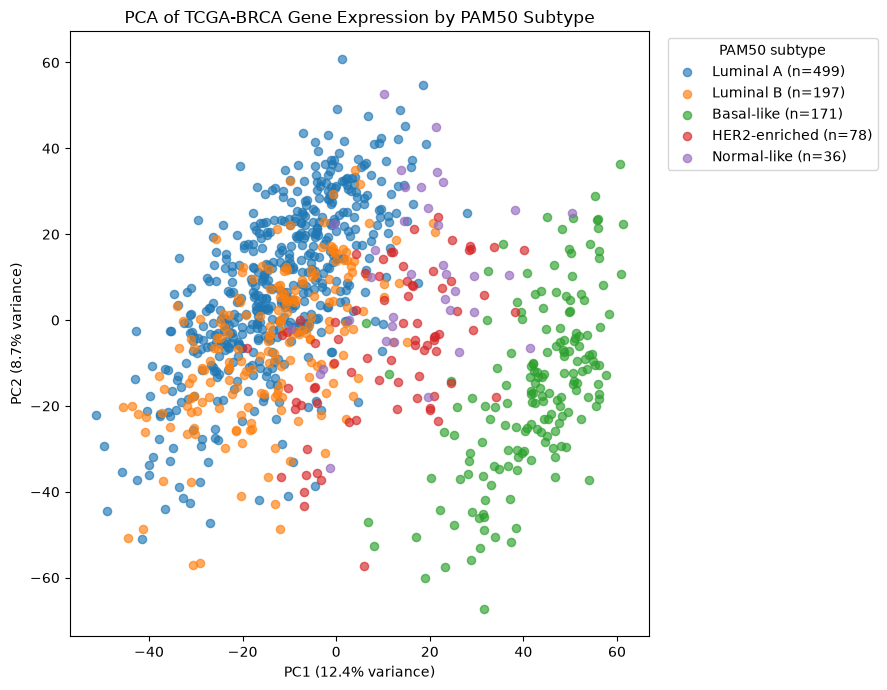

In [31]:
# PCA visualization by PAM50 subtype

subtype_order = [
    "Luminal A",
    "Luminal B",
    "Basal-like",
    "HER2-enriched",
    "Normal-like"
]

plt.figure(figsize=(9, 7))

for subtype in subtype_order:
    subset = pca_df[
        pca_df["pam50_subtype"] == subtype
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=35,
        alpha=0.65,
        label=f"{subtype} (n={len(subset)})"
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title(
    "PCA of TCGA-BRCA Gene Expression by PAM50 Subtype"
)

plt.legend(
    title="PAM50 subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [32]:
# PCA QC summary

print("=== PCA QC ===")

print("Samples used:", pca_input.shape[0])
print("Genes used:", pca_input.shape[1])

print(
    f"PC1 explained variance: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)

print(
    f"PC2 explained variance: "
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)

print(
    f"PC1 + PC2 explained variance: "
    f"{pca.explained_variance_ratio_[:2].sum() * 100:.2f}%"
)

print("\nPAM50 counts:")
print(
    pca_df["pam50_subtype"]
    .value_counts()
)

=== PCA QC ===
Samples used: 981
Genes used: 5000
PC1 explained variance: 12.38%
PC2 explained variance: 8.73%
PC1 + PC2 explained variance: 21.11%

PAM50 counts:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


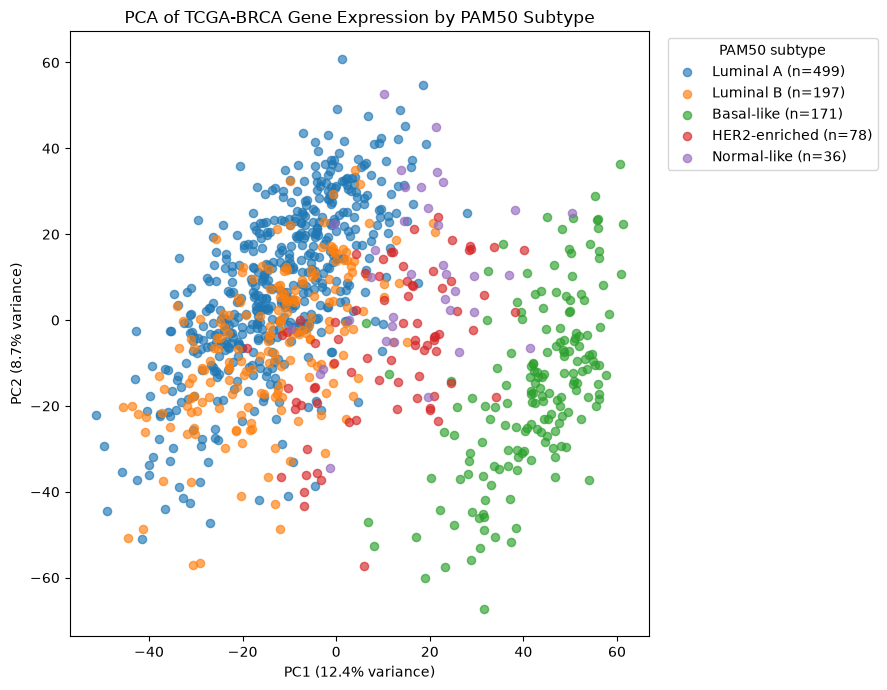

Saved PCA figure to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/figures/06_pam50_expression_pca.png


In [33]:
# Save PCA figure

pca_figure_path = figures_dir / "06_pam50_expression_pca.png"

plt.figure(figsize=(9, 7))

for subtype in subtype_order:
    subset = pca_df[
        pca_df["pam50_subtype"] == subtype
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=35,
        alpha=0.65,
        label=f"{subtype} (n={len(subset)})"
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title(
    "PCA of TCGA-BRCA Gene Expression by PAM50 Subtype"
)

plt.legend(
    title="PAM50 subtype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    pca_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved PCA figure to:")
print(pca_figure_path)

In [34]:
# Calculate PCA gene loadings

pca_loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=pca_input.columns,
    columns=["PC1_loading", "PC2_loading"]
)

print("PCA loading table shape:")
print(pca_loadings.shape)

display(pca_loadings.head())

PCA loading table shape:
(5000, 2)


,PC1_loading,PC2_loading
Ensembl_ID,,
ENSG00000166509.12,-0.012110,0.007474
ENSG00000110484.7,-0.013372,0.015797
ENSG00000153002.12,-0.018873,0.008256
ENSG00000134184.13,-0.003042,0.004601
ENSG00000162989.5,-0.022931,0.006939


In [35]:
# Genes contributing most strongly to PC1

top_pc1_positive = (
    pca_loadings
    .sort_values("PC1_loading", ascending=False)
    .head(15)
)

top_pc1_negative = (
    pca_loadings
    .sort_values("PC1_loading")
    .head(15)
)

print("Top positive PC1 loadings:")
display(top_pc1_positive)

print("\nTop negative PC1 loadings:")
display(top_pc1_negative)

Top positive PC1 loadings:


,PC1_loading,PC2_loading
Ensembl_ID,,
ENSG00000119866.22,0.033116,0.007020
ENSG00000135069.14,0.032559,-0.004167
ENSG00000280916.2,0.032381,-0.006543
ENSG00000054598.9,0.031936,0.000858
ENSG00000156219.17,0.031883,-0.003209
ENSG00000102243.13,0.031355,0.000011
ENSG00000287313.1,0.031163,-0.002713
ENSG00000198729.5,0.030917,0.000741
ENSG00000118849.10,0.030693,0.007330



Top negative PC1 loadings:


,PC1_loading,PC2_loading
Ensembl_ID,,
ENSG00000091831.24,-0.032348,0.016167
ENSG00000115648.14,-0.032058,0.017221
ENSG00000129514.8,-0.031988,0.017413
ENSG00000248360.7,-0.031567,0.020067
ENSG00000139865.16,-0.031187,0.019446
ENSG00000107485.18,-0.031175,0.014946
ENSG00000173467.9,-0.031110,0.017474
ENSG00000225362.10,-0.031085,0.018802
ENSG00000074410.14,-0.030603,0.017837


In [36]:
# Genes contributing most strongly to PC2

top_pc2_positive = (
    pca_loadings
    .sort_values("PC2_loading", ascending=False)
    .head(15)
)

top_pc2_negative = (
    pca_loadings
    .sort_values("PC2_loading")
    .head(15)
)

print("Top positive PC2 loadings:")
display(top_pc2_positive)

print("\nTop negative PC2 loadings:")
display(top_pc2_negative)

Top positive PC2 loadings:


,PC1_loading,PC2_loading
Ensembl_ID,,
ENSG00000154258.17,0.000041,0.039222
ENSG00000164946.20,0.008630,0.037638
ENSG00000154175.18,0.004320,0.037573
ENSG00000231246.2,0.003753,0.037411
ENSG00000017427.17,0.002051,0.037113
ENSG00000141338.14,-0.000189,0.037054
ENSG00000166482.12,0.001010,0.037018
ENSG00000196569.13,-0.003090,0.036426
ENSG00000187955.12,-0.003081,0.036400



Top negative PC2 loadings:


,PC1_loading,PC2_loading
Ensembl_ID,,
ENSG00000128564.7,0.009589,-0.015875
ENSG00000107159.13,0.018123,-0.015294
ENSG00000167771.6,0.018239,-0.013573
ENSG00000189001.11,0.023459,-0.013028
ENSG00000258314.3,0.023385,-0.012727
ENSG00000181418.8,0.021558,-0.012431
ENSG00000225255.6,0.021320,-0.012357
ENSG00000137090.12,0.023011,-0.011831
ENSG00000173237.4,0.024972,-0.011737


In [37]:
# Save PCA sample coordinates

pca_results_path = results_dir / "06_pam50_expression_pca_coordinates.csv"

pca_df.to_csv(
    pca_results_path,
    index=True,
    index_label="sample_id"
)

print("Saved PCA coordinates to:")
print(pca_results_path)

Saved PCA coordinates to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/06_pam50_expression_pca_coordinates.csv


In [38]:
# Remove Ensembl version suffix for gene annotation

pca_loadings_annot = pca_loadings.copy()

pca_loadings_annot["Ensembl_ID_versioned"] = (
    pca_loadings_annot.index
)

pca_loadings_annot["Ensembl_ID"] = (
    pca_loadings_annot["Ensembl_ID_versioned"]
    .str.split(".")
    .str[0]
)

print("Example:")
display(
    pca_loadings_annot[
        ["Ensembl_ID_versioned", "Ensembl_ID"]
    ].head()
)

Example:


,Ensembl_ID_versioned,Ensembl_ID
Ensembl_ID,,
ENSG00000166509.12,ENSG00000166509.12,ENSG00000166509
ENSG00000110484.7,ENSG00000110484.7,ENSG00000110484
ENSG00000153002.12,ENSG00000153002.12,ENSG00000153002
ENSG00000134184.13,ENSG00000134184.13,ENSG00000134184
ENSG00000162989.5,ENSG00000162989.5,ENSG00000162989


In [39]:
# Use manually downloaded GENCODE v36 annotation

gencode_file = raw_dir / "gencode.v36.annotation.gtf.gz"

print("GENCODE file path:")
print(gencode_file)

print("\nFile exists:")
print(gencode_file.exists())

if gencode_file.exists():
    print(
        f"File size: "
        f"{gencode_file.stat().st_size / (1024**2):.2f} MB"
    )
    

GENCODE file path:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/data/raw/gencode.v36.annotation.gtf.gz

File exists:
True
File size: 42.45 MB


In [40]:
# Extract gene ID and gene symbol from GENCODE GTF

gencode_gtf = pd.read_csv(
    gencode_file,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chromosome",
        "source",
        "feature",
        "start",
        "end",
        "score",
        "strand",
        "frame",
        "attribute"
    ],
    compression="gzip"
)

genes_gtf = gencode_gtf[
    gencode_gtf["feature"] == "gene"
].copy()

genes_gtf["Ensembl_ID"] = (
    genes_gtf["attribute"]
    .str.extract(r'gene_id "([^"]+)"')[0]
    .str.split(".")
    .str[0]
)

genes_gtf["gene_symbol"] = (
    genes_gtf["attribute"]
    .str.extract(r'gene_name "([^"]+)"')[0]
)

gene_annotation = (
    genes_gtf[
        ["Ensembl_ID", "gene_symbol"]
    ]
    .drop_duplicates()
)

print("Gene annotation rows:", len(gene_annotation))

display(gene_annotation.head())

Gene annotation rows: 60616


,Ensembl_ID,gene_symbol
0,ENSG00000223972,DDX11L1
12,ENSG00000227232,WASH7P
25,ENSG00000278267,MIR6859-1
28,ENSG00000243485,MIR1302-2HG
36,ENSG00000284332,MIR1302-2


In [41]:
# Add gene symbols to PCA loadings

pca_loadings_annot = pca_loadings.copy()

pca_loadings_annot["Ensembl_ID_versioned"] = (
    pca_loadings_annot.index
)

pca_loadings_annot["Ensembl_ID"] = (
    pca_loadings_annot["Ensembl_ID_versioned"]
    .str.split(".")
    .str[0]
)

pca_loadings_annot = (
    pca_loadings_annot
    .reset_index(drop=True)
    .merge(
        gene_annotation,
        on="Ensembl_ID",
        how="left"
    )
)

print(
    "Genes with mapped symbols:",
    pca_loadings_annot["gene_symbol"].notna().sum()
)

print(
    "Genes without mapped symbols:",
    pca_loadings_annot["gene_symbol"].isna().sum()
)

display(pca_loadings_annot.head())

Genes with mapped symbols: 5000
Genes without mapped symbols: 0


,PC1_loading,PC2_loading,Ensembl_ID_versioned,Ensembl_ID,gene_symbol
0,-0.012110,0.007474,ENSG00000166509.12,ENSG00000166509,CLEC3A
1,-0.013372,0.015797,ENSG00000110484.7,ENSG00000110484,SCGB2A2
2,-0.018873,0.008256,ENSG00000153002.12,ENSG00000153002,CPB1
3,-0.003042,0.004601,ENSG00000134184.13,ENSG00000134184,GSTM1
4,-0.022931,0.006939,ENSG00000162989.5,ENSG00000162989,KCNJ3


In [42]:
# Top PC1 genes with gene symbols

top_pc1_positive_annot = (
    pca_loadings_annot
    .sort_values("PC1_loading", ascending=False)
    .head(15)
)

top_pc1_negative_annot = (
    pca_loadings_annot
    .sort_values("PC1_loading")
    .head(15)
)

print("Top positive PC1 genes:")
display(
    top_pc1_positive_annot[
        ["gene_symbol", "Ensembl_ID_versioned", "PC1_loading"]
    ]
)

print("\nTop negative PC1 genes:")
display(
    top_pc1_negative_annot[
        ["gene_symbol", "Ensembl_ID_versioned", "PC1_loading"]
    ]
)

Top positive PC1 genes:


,gene_symbol,Ensembl_ID_versioned,PC1_loading
827,BCL11A,ENSG00000119866.22,0.033116
1067,PSAT1,ENSG00000135069.14,0.032559
306,FOXCUT,ENSG00000280916.2,0.032381
2425,FOXC1,ENSG00000054598.9,0.031936
244,ART3,ENSG00000156219.17,0.031883
89,VGLL1,ENSG00000102243.13,0.031355
1670,AC016995.1,ENSG00000287313.1,0.031163
496,PPP1R14C,ENSG00000198729.5,0.030917
1591,RARRES1,ENSG00000118849.10,0.030693
1217,LINC02732,ENSG00000254416.6,0.030667



Top negative PC1 genes:


,gene_symbol,Ensembl_ID_versioned,PC1_loading
189,ESR1,ENSG00000091831.24,-0.032348
1272,MLPH,ENSG00000115648.14,-0.032058
494,FOXA1,ENSG00000129514.8,-0.031988
481,LINC00504,ENSG00000248360.7,-0.031567
509,TTC6,ENSG00000139865.16,-0.031187
1719,GATA3,ENSG00000107485.18,-0.031175
29,AGR3,ENSG00000173467.9,-0.031110
422,CT62,ENSG00000225362.10,-0.031085
926,CA12,ENSG00000074410.14,-0.030603
1846,THSD4,ENSG00000187720.14,-0.030423


In [43]:
# Inspect top negative PC1 genes

print("Top negative PC1 genes:")

display(
    top_pc1_negative_annot[
        [
            "gene_symbol",
            "Ensembl_ID_versioned",
            "PC1_loading"
        ]
    ]
)

Top negative PC1 genes:


,gene_symbol,Ensembl_ID_versioned,PC1_loading
189,ESR1,ENSG00000091831.24,-0.032348
1272,MLPH,ENSG00000115648.14,-0.032058
494,FOXA1,ENSG00000129514.8,-0.031988
481,LINC00504,ENSG00000248360.7,-0.031567
509,TTC6,ENSG00000139865.16,-0.031187
1719,GATA3,ENSG00000107485.18,-0.031175
29,AGR3,ENSG00000173467.9,-0.031110
422,CT62,ENSG00000225362.10,-0.031085
926,CA12,ENSG00000074410.14,-0.030603
1846,THSD4,ENSG00000187720.14,-0.030423


In [45]:
# Build gene symbol to Ensembl ID mapping

symbol_to_ensembl = (
    gene_annotation
    .dropna(subset=["gene_symbol"])
    .drop_duplicates(subset="gene_symbol")
    .set_index("gene_symbol")["Ensembl_ID"]
)

marker_genes = [
    "ESR1",
    "PGR",
    "GATA3",
    "FOXA1",
    "ERBB2",
    "FOXC1",
    "KRT5",
    "KRT14",
    "KRT17"
]

print("Marker gene mapping:")

for gene in marker_genes:
    if gene in symbol_to_ensembl.index:
        print(
            gene,
            "->",
            symbol_to_ensembl.loc[gene]
        )
    else:
        print(gene, "-> NOT FOUND")

Marker gene mapping:
ESR1 -> ENSG00000091831
PGR -> ENSG00000082175
GATA3 -> ENSG00000107485
FOXA1 -> ENSG00000129514
ERBB2 -> ENSG00000141736
FOXC1 -> ENSG00000054598
KRT5 -> ENSG00000186081
KRT14 -> ENSG00000186847
KRT17 -> ENSG00000128422


In [44]:
# Save annotated PCA gene loadings

pca_loadings_path = (
    results_dir / "06_pca_gene_loadings_annotated.csv"
)

pca_loadings_annot.to_csv(
    pca_loadings_path,
    index=False
)

print("Saved annotated PCA loadings to:")
print(pca_loadings_path)

Saved annotated PCA loadings to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/06_pca_gene_loadings_annotated.csv


In [46]:
# Create version-free Ensembl IDs for expression matrix

expr_marker = expr_matrix.copy()

expr_marker.index = (
    expr_marker.index
    .str.split(".")
    .str[0]
)

print("Expression matrix shape:", expr_marker.shape)

print(
    "Duplicated version-free Ensembl IDs:",
    expr_marker.index.duplicated().sum()
)

Expression matrix shape: (60660, 981)
Duplicated version-free Ensembl IDs: 44


In [47]:
# Extract marker gene expression

marker_ensembl_ids = [
    symbol_to_ensembl.loc[gene]
    for gene in marker_genes
]

marker_expression = (
    expr_marker
    .loc[marker_ensembl_ids]
    .copy()
)

marker_expression.index = marker_genes

print("Marker expression matrix shape:")
print(marker_expression.shape)

display(marker_expression.iloc[:, :5])

Marker expression matrix shape:
(9, 981)


,TCGA-3C-AAAU-01A,TCGA-3C-AALI-01A,TCGA-3C-AALJ-01A,TCGA-3C-AALK-01A,TCGA-4H-AAAK-01A
ESR1,13.397006,7.312883,13.095067,12.639793,13.754470
PGR,12.720672,5.781360,9.142107,12.461479,13.385053
GATA3,15.493824,13.885982,13.649593,14.526010,15.148079
FOXA1,14.036946,13.535154,12.412305,14.204265,14.051124
ERBB2,14.382692,18.487860,13.566530,16.414239,14.838810
FOXC1,5.930737,6.794416,7.569856,9.432542,8.543032
KRT5,2.807355,9.620220,3.000000,13.119103,12.746514
KRT14,0.000000,9.192293,2.321928,13.465311,12.737036
KRT17,1.000000,10.250298,3.906891,13.772521,12.869594


In [48]:
# Check whether marker genes are affected by duplicated Ensembl IDs

duplicated_ensembl_ids = (
    expr_marker.index[
        expr_marker.index.duplicated(keep=False)
    ]
    .unique()
)

marker_duplicate_check = [
    gene
    for gene in marker_ensembl_ids
    if gene in duplicated_ensembl_ids
]

print("Duplicated version-free Ensembl IDs:", len(duplicated_ensembl_ids))
print("Marker genes affected by duplicates:", len(marker_duplicate_check))

if marker_duplicate_check:
    print(marker_duplicate_check)
else:
    print("None of the selected marker genes are affected.")

Duplicated version-free Ensembl IDs: 44
Marker genes affected by duplicates: 0
None of the selected marker genes are affected.


In [49]:
# Combine marker expression with PAM50 subtype metadata

marker_sample_df = marker_expression.T.copy()

marker_sample_df = marker_sample_df.join(
    matched_samples_unique
    .set_index("sample_id")[["pam50_subtype"]],
    how="left"
)

print("Marker sample table shape:", marker_sample_df.shape)

print(
    "Missing PAM50 annotations:",
    marker_sample_df["pam50_subtype"].isna().sum()
)

display(marker_sample_df.head())

Marker sample table shape: (981, 10)
Missing PAM50 annotations: 0


,ESR1,PGR,GATA3,FOXA1,ERBB2,FOXC1,KRT5,KRT14,KRT17,pam50_subtype
TCGA-3C-AAAU-01A,13.397006,12.720672,15.493824,14.036946,14.382692,5.930737,2.807355,0.000000,1.000000,Luminal A
TCGA-3C-AALI-01A,7.312883,5.781360,13.885982,13.535154,18.487860,6.794416,9.620220,9.192293,10.250298,HER2-enriched
TCGA-3C-AALJ-01A,13.095067,9.142107,13.649593,12.412305,13.566530,7.569856,3.000000,2.321928,3.906891,Luminal B
TCGA-3C-AALK-01A,12.639793,12.461479,14.526010,14.204265,16.414239,9.432542,13.119103,13.465311,13.772521,Luminal A
TCGA-4H-AAAK-01A,13.754470,13.385053,15.148079,14.051124,14.838810,8.543032,12.746514,12.737036,12.869594,Luminal A


In [52]:
# Mean marker expression by PAM50 subtype

marker_subtype_mean = (
    marker_sample_df
    .groupby("pam50_subtype")[marker_genes]
    .mean()
    .reindex(subtype_order)
)

print("Mean marker expression by PAM50 subtype:")

display(marker_subtype_mean.round(2))

Mean marker expression by PAM50 subtype:


,ESR1,PGR,GATA3,FOXA1,ERBB2,FOXC1,KRT5,KRT14,KRT17
pam50_subtype,,,,,,,,,
Luminal A,14.87,12.41,15.29,14.37,14.43,8.54,10.93,10.56,10.94
Luminal B,15.25,11.00,15.43,14.57,14.54,7.73,8.02,7.35,8.25
Basal-like,8.31,6.05,10.87,7.87,13.28,12.41,13.51,11.75,13.33
HER2-enriched,9.64,7.17,13.17,13.97,17.05,7.96,9.54,7.91,9.86
Normal-like,11.51,9.98,12.96,12.23,14.07,10.23,14.52,13.89,13.86


In [53]:
# Heatmap of PAM50-associated marker genes

heatmap_data = marker_subtype_z.T

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("PAM50 subtype")
ax.set_ylabel("Marker gene")

ax.set_title(
    "PAM50 Subtype-Specific Breast Cancer Marker Expression"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative expression (z-score)")

plt.tight_layout()
plt.show()

NameError: name 'marker_subtype_z' is not defined

In [54]:
# Mean marker expression by PAM50 subtype

marker_subtype_mean = (
    marker_sample_df
    .groupby("pam50_subtype")[marker_genes]
    .mean()
    .reindex(subtype_order)
)

display(marker_subtype_mean.round(2))

,ESR1,PGR,GATA3,FOXA1,ERBB2,FOXC1,KRT5,KRT14,KRT17
pam50_subtype,,,,,,,,,
Luminal A,14.87,12.41,15.29,14.37,14.43,8.54,10.93,10.56,10.94
Luminal B,15.25,11.00,15.43,14.57,14.54,7.73,8.02,7.35,8.25
Basal-like,8.31,6.05,10.87,7.87,13.28,12.41,13.51,11.75,13.33
HER2-enriched,9.64,7.17,13.17,13.97,17.05,7.96,9.54,7.91,9.86
Normal-like,11.51,9.98,12.96,12.23,14.07,10.23,14.52,13.89,13.86


In [55]:
# Z-score marker expression across PAM50 subtypes

marker_subtype_z = (
    marker_subtype_mean
    .sub(marker_subtype_mean.mean(axis=0), axis=1)
    .div(marker_subtype_mean.std(axis=0), axis=1)
)

display(marker_subtype_z.round(2))

,ESR1,PGR,GATA3,FOXA1,ERBB2,FOXC1,KRT5,KRT14,KRT17
pam50_subtype,,,,,,,,,
Luminal A,0.96,1.16,0.93,0.63,-0.17,-0.43,-0.14,0.10,-0.13
Luminal B,1.08,0.63,1.00,0.70,-0.09,-0.84,-1.22,-1.08,-1.27
Basal-like,-1.17,-1.23,-1.42,-1.69,-0.99,1.55,0.82,0.54,0.88
HER2-enriched,-0.74,-0.81,-0.20,0.49,1.68,-0.72,-0.65,-0.88,-0.59
Normal-like,-0.13,0.25,-0.31,-0.13,-0.43,0.44,1.19,1.33,1.11


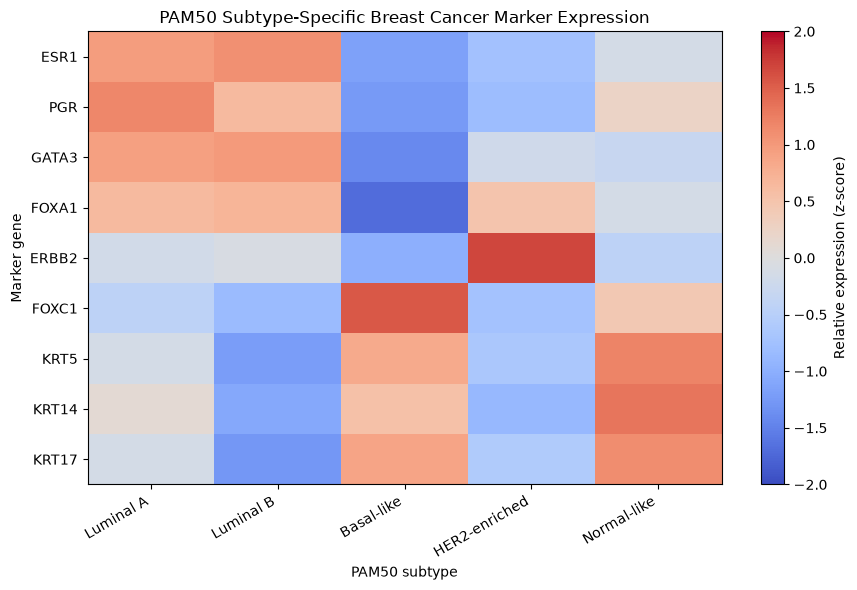

In [56]:
# Heatmap of PAM50-associated marker genes

heatmap_data = marker_subtype_z.T

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("PAM50 subtype")
ax.set_ylabel("Marker gene")
ax.set_title(
    "PAM50 Subtype-Specific Breast Cancer Marker Expression"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative expression (z-score)")

plt.tight_layout()
plt.show()

In [57]:
# Save PAM50 marker heatmap

marker_heatmap_path = (
    figures_dir / "06_pam50_marker_expression_heatmap.png"
)

fig.savefig(
    marker_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved marker heatmap to:")
print(marker_heatmap_path)

Saved marker heatmap to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/figures/06_pam50_marker_expression_heatmap.png


In [58]:
# Save mean marker expression by PAM50 subtype

marker_mean_path = (
    results_dir / "06_pam50_marker_mean_expression.csv"
)

marker_subtype_mean.to_csv(marker_mean_path)

print("Saved marker expression results to:")
print(marker_mean_path)

Saved marker expression results to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/06_pam50_marker_mean_expression.csv


In [59]:
# Save standardized marker expression

marker_z_path = (
    results_dir / "06_pam50_marker_zscores.csv"
)

marker_subtype_z.to_csv(marker_z_path)

print("Saved marker z-scores to:")
print(marker_z_path)

Saved marker z-scores to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/results/06_pam50_marker_zscores.csv


In [60]:
# Final QC for Notebook 06

print("=== FINAL GENE EXPRESSION ANALYSIS QC ===")

print(f"Total TCGA-BRCA RNA-seq samples: {len(sample_metadata)}")
print(f"Primary tumor RNA-seq samples: {len(primary_tumor_metadata)}")
print(f"PAM50-matched unique patients: {len(matched_samples_unique)}")

print(f"\nGenes in full expression matrix: {expr_matrix.shape[0]}")
print(f"Genes after expression filtering: {expr_filtered.shape[0]}")
print(f"Highly variable genes used for PCA: {pca_input.shape[1]}")

print(f"\nPCA samples: {pca_input.shape[0]}")
print(
    f"PC1 explained variance: "
    f"{pca.explained_variance_ratio_[0] * 100:.2f}%"
)
print(
    f"PC2 explained variance: "
    f"{pca.explained_variance_ratio_[1] * 100:.2f}%"
)
print(
    f"PC1 + PC2 explained variance: "
    f"{pca.explained_variance_ratio_[:2].sum() * 100:.2f}%"
)

print("\nPAM50 subtype distribution:")
print(
    matched_samples_unique["pam50_subtype"]
    .value_counts()
)

print("\nGene annotation:")
print(
    "Mapped PCA genes:",
    pca_loadings_annot["gene_symbol"].notna().sum()
)
print(
    "Unmapped PCA genes:",
    pca_loadings_annot["gene_symbol"].isna().sum()
)

print("\nMarker genes analysed:")
print(", ".join(marker_genes))

=== FINAL GENE EXPRESSION ANALYSIS QC ===
Total TCGA-BRCA RNA-seq samples: 1226
Primary tumor RNA-seq samples: 1106
PAM50-matched unique patients: 981

Genes in full expression matrix: 60660
Genes after expression filtering: 33416
Highly variable genes used for PCA: 5000

PCA samples: 981
PC1 explained variance: 12.38%
PC2 explained variance: 8.73%
PC1 + PC2 explained variance: 21.11%

PAM50 subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64

Gene annotation:
Mapped PCA genes: 5000
Unmapped PCA genes: 0

Marker genes analysed:
ESR1, PGR, GATA3, FOXA1, ERBB2, FOXC1, KRT5, KRT14, KRT17


In [61]:
# Save final RNA-seq sample metadata for downstream analyses

expression_metadata_path = (
    processed_dir / "tcga_brca_expression_pam50_metadata.csv"
)

matched_samples_unique.to_csv(
    expression_metadata_path,
    index=False
)

print("Saved expression metadata to:")
print(expression_metadata_path)

Saved expression metadata to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/01_TCGA_BRCA/data/processed/tcga_brca_expression_pam50_metadata.csv
